---
layout: article
title: How to Invest 2000 Dollars in the Optimal Way? - Part I
custom_css: article.css
include_mathjax: true
---

In [1]:
import os
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
from matplotlib.ticker import FormatStrFormatter

# define watermark 
def add_watermark(ax, x, y):
    ax.text(ax.get_xlim()[0]+ x,
            ax.get_ylim()[0]+ y,
            "ladydragoncapital",
            alpha=0.3, fontsize=16)



If you have 2000 dollars in spare, how can you invest it to maximize the returned advantage?

## Introduction ##

Before we answer the question on how to maximize advantage, let's first define advantage.

The advantage of an investment includes the following two aspects:

+ Safety

  To increase the safety of the investment, portfolio diversification is very crucial, because it can decrease the impact of any single investment on your overall portfolio. Portfolio diversification can be done through the following ways:

    + Regions: Investing in foreign jurisdictions
    + Asset classes: Different asset classes include real estate, stocks, bonds, etc..
      
+ Interest

  By choosing the certain asset classes in the certain countries, we can increase the interest of our investment.

In this article, part I of the whole series to answer the aforementioned question, we will discuss the advantage of investing offshore.


## Investing offshore ##

Benefits:

Investment in foreign jurisdictions can potentially:
  + lower the threat of the political instability of your own nation
  + lower the threat of the economic instability of your own nation
  + protect your assets from potential legal attacks
  + increase the return on the investment
    
Potential problems:
  + Tax complications and more complex regulations
  + Limited resource in disputes
  + Higher cost for setup, maintenance, and withdrawing fund
    

Conditions:

Investing offshore often requires higher setup fees and more complex process, which needs to be considered into our decision making. For example:
  + High initial deposit
    
    For instance, to open an on-line expat account with [HSBC](https://expatexplorer.hsbc.com/apply/), one of the major international banks in the world, you have to meet **one** of the following criteria:
    
      + Save or invest at least 75,000 euros within 3 months of opening your account
      + Have an annual salary of at least 120,000 euros which must be paid to your HSBC Expat account
      + Already be an HSBC Premier customer in another country or region.
        
  + High balance
    
    For instance, [Citibank](https://www.citibank.com.sg/en) in Singapore requires you to keep a 200,000 SGD (1 SGD = 0.75 USD, Nov. 2024).
    
  + Personal visit
    
    Some banks require you to be present personally to open an account, for instance, banks at [Dubai]( https://www.uae-eu.com/blog/opening-uae-bank-account-from-abroad.html) require you to physically visit the bank when opening an account, or hire a financial consultant to represent you.


## Calculate the advantage of investing offshore ##

To measure the advantage of investing, we use the number of months ($N$) that the interest earned from the investment can sustain our living expenses, based on the interest rate ($I$) and the cost of living ($C$). By comparing the $N$ values for investments in different countries, we can determine which option is more advantageous.

We want to understand which country offers policies (interest rate, cost of living, and required amount for the investor visa) that can maximize the following $\Delta{N}$:

$$
\Delta{N} = N_{foreign} - N_{domestic}
$$

$N_{foreign}$: The number of months the return interest of our investment in the foreign country can purchase.

$N_{domestic}$: The number of months the return interest of our investment in the home nation can purchase.

$N$ is calculated through the following equation:

$$
N = \frac{IP(1-T)- F}{C}
$$

$I$: Annual interest rate

$P$: Principal

$T$: Tax rate for transferring the money back to the home nation, only applicable when the investor is living in the home nation but investing offshore

$F$: Fees, including fees for opening an account, wiring money, maintaining an account, etc..

$C$: Cost of living


Due to the fact that when the investment is large enough, the investor can acquire the investor visa and access the cost of living in the foreign country, we need to consider the following two scenarios:

If your investment ($P$) is smaller than the required amount for the investor visa ($P_{visa}$), i.e. P < $P_{visa}$, the investor stays in the home nation and the cost of living stays the same:
$$
\Delta{N} = \frac{I_{foreign}P(1-T) - F_{foreign}}{C_{domestic}} - \frac{I_{domestic}P - F_{domestic}}{C_{domestic}}
$$

However, when $P$ >= $P_{visa}$, this investment will provide us with the investor visa, and allow us to immigrate to the foreign country and enjoy their cost of living:
$$
\Delta{N} = \frac{I_{foreign}P - F_{foreign}}{C_{foreign}} - \frac{I_{domestic}P - F_{domestic}}{C_{domestic}}
$$




In [2]:
# get optimization libs

def calculate_domestic_n(i_dom: float, P: float, C_dom: float, F_dom: float):
    """Calculate the roi of investing domestically"""
    n_dom = (i_dom * P - F_dom) / (C_dom/30)

    return n_dom

def calculate_foreign_n(P: float, P_visa: float, i_for: float, t: float, C_dom, C_for: float, F_for: float):
    """Calculate the roi of investing offshore"""
    # if the principal is smaller than the required amount for the investor visa
    if P < P_visa:
        n_for = (i_for * P * (1-t) - F_for) / (C_dom) 
    # if the principal is larger than the required amount for the investor visa
    else:
        n_for = (i_for * P - F_for) / (C_for)
    return n_for

# define functions
def calculate_delta_n(i_dom: float, P: float, C_dom: float, F_dom: float, P_visa: float, i_for: float, t: float, C_for: float, F_for: float):
    """Calculate the ΔN given the initial values for rent, col, and wealth."""
    # get all roi terms
    n_dom = (i_dom * P - F_dom) / (C_dom)
    if P < P_visa:
        n_for = (i_for * P * (1-t) - F_for) / (C_dom)
    else:
        n_for = (i_for * P - F_for) / (C_for)
                                         
    # calculate delta ROI
    delta_n = n_for - n_dom

    # finished
    return delta_n

def absolute_objective_function(*args, **kwargs):
    """Calculate absolute value for objective function."""
    return abs(calculate_delta_n(*args, **kwargs))


Let's calculate two examples to understand how a country's policies (interest rate, cost of living, and required amount for the investor visa) can affect $\Delta{N}$.

## Ecuador vs. America ##

In this example, Ecuador is the foreign country and America domestic. Here are the relevant policies of Ecuador:

+ Annual Interest rate: 6.50% for one year certificate of deposit ([Banco Pichincha](https://www.pichincha.com/detalle-producto/personas-inversiones-plazodolar))
+ Cost of living: 532.2 USD/month
+ Required investment for the investor visa: 40,000 USD
+ Tax rate for transfer the money out of Ecuador: 5%
+ Fees for opening a bank account and wire transfer: ~ 50 USD

The relevant policies of America:
+ Annual Interest rate: 3.35% for one year certificate of deposit ([Bank of America](https://www.bankofamerica.com/deposits/bank-cds/cd-accounts/?cm_mmc=DEP-Checking-_-Google-PS-_-Compare-CD-Options-Sitelink-_-Brand_Checking&cq_src=google_ads&cq_med=Deposits&cq_cmp=20763011518&cq_term=bank%20of%20america%20cd%20rates&cq_net=g&cq_plt=gp&gad_source=1&gclid=CjwKCAiAneK8BhAVEiwAoy2HYSjU58wtWBjV8Mnbmvggdd99cjFDI27FuBIiShQI1WLQY))
+ Cost of living: 1164.3 USD/month
+ Fees for opening an account: 0

As shown in Figure 1, regardless of the investment amount, the additional months ($\Delta{N}$) remain positive and continue to grow as the investment increases, driven by the higher interest rate (6.50% vs. 3.35% for Ecuador vs. America, respectively). When the investment reaches 40,000 USD, $\Delta{N}$ experiences a sharp rise (jumping from less than 1 to over 3.5) because the investment becomes sufficient to qualify for an investor visa, and the cost of living shifts from domestic (1164.3 USD/month) to foreign (532.2 USD/month). Beyond this threshold, the rate at which $\Delta{N}$ grows accelerates.

On the other hand, the orange line indicates that investing 2,000 USD in Ecuador offers more months than in America. However, the $\Delta{N}$ value (0.05) is too small to justify the effort. That said, if you have 40,000 USD in spare and are considering relocating to a country with a lower cost of living, investing in Ecuador could potentially offer a significantly greater advantage. In the following articles, we will explore how much the total wealth needs to be, in order to justify this investment of 40,000 USD.


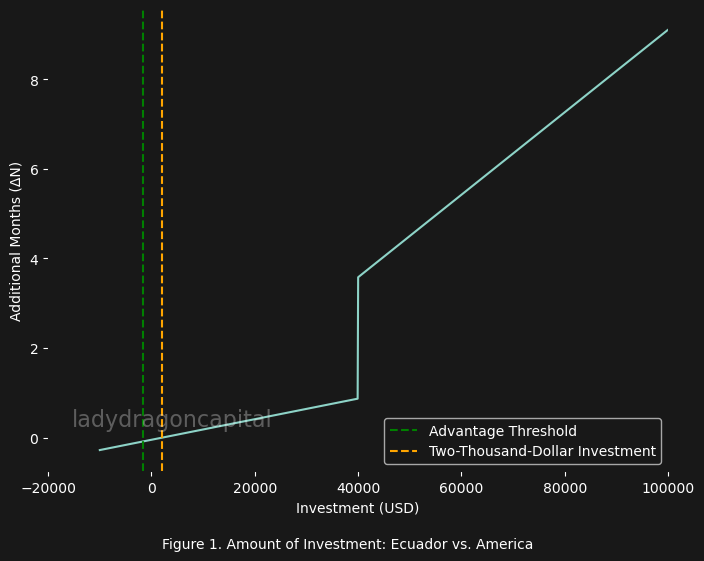

In [3]:
# get optimization libs
from scipy.optimize import minimize

fig_count = 1
# set the style to a dark theme
plt.style.use("dark_background")

# match website background
plt.rcParams["figure.facecolor"] = "#181818"
plt.rcParams["axes.facecolor"] = "#181818"
plt.rcParams["axes.edgecolor"] = "#181818"

# set values
I_dom = 0.035
C_dom = 1164.4
F_dom = 0
P_visaec = 40000
I_ec = 0.065
t_ec = 0.05
C_ec = 532.2
F_ec = 55


fig, ax = plt.subplots(figsize=(8, 6))

# ind the value of p that minimizes the absolute value of the objective function
result = minimize(absolute_objective_function, 0.5, args=(I_dom, C_dom, F_dom, P_visaec, I_ec, t_ec, C_ec, F_ec))

# Extract the optimal value of x
threshold_p = result.x[0]

# generate p/ΔN pairs
p_values = np.arange(-10000, 100000, 100)
delta_n_values = np.array([calculate_delta_n(I_dom, p, C_dom, F_dom, P_visaec, I_ec, t_ec, C_ec, F_ec) for p in p_values])

# plotting the data
plt.plot(p_values, delta_n_values)

# plot threshold p value and target 2000 value
plt.axvline(x=threshold_p, color='green', linestyle='--', label='Advantage Threshold')
plt.axvline(x=2000, color='orange', linestyle='--', label='Two-Thousand-Dollar Investment')

# add watermark
add_watermark(ax, 1, 1)

# adding labels and title
plt.xlabel("Investment (USD)")
plt.ylabel("Additional Months (ΔN)")
plt.xlim([-20000,100000])
# set title
plt.suptitle(
    f"Figure {fig_count}. Amount of Investment: Ecuador vs. America", y=0.0001, fontsize=10
)
fig_count += 1

# displaying the plot
plt.legend()
plt.show()

## Singapore vs. America ##

In this example, Singapore is the foreign country and America domestic. Here are the relevant policies of Singapore:

+ Annual Interest rate: 2.60% for one year certificate of deposit ([Standard Chartered Bank](https://www.sc.com/sg/save/time-deposits/singapore-dollar-time-deposit/#:~:text=For%20a%20limited%20time%20only,Priority%20Private:%202.88%25%20p.a.))
+ Cost of living: 1120.0 USD/month
+ Required investment for the investor visa: 1.88 million
+ Tax rate for transfer the money out of Singapore: 0
+ Fees for opening a bank account and wire transfer: ~ 50 USD
+ Initial deposit: 37,500 USD

The relevant policies of America:
+ Annual Interest rate: 3.35% for one year certificate of deposit ([Bank of America](https://www.bankofamerica.com/deposits/bank-cds/cd-accounts/?cm_mmc=DEP-Checking-_-Google-PS-_-Compare-CD-Options-Sitelink-_-Brand_Checking&cq_src=google_ads&cq_med=Deposits&cq_cmp=20763011518&cq_term=bank%20of%20america%20cd%20rates&cq_net=g&cq_plt=gp&gad_source=1&gclid=CjwKCAiAneK8BhAVEiwAoy2HYSjU58wtWBjV8Mnbmvggdd99cjFDI27FuBIiShQI1WLQY))
+ Cost of living: 1164.3 USD/month
+ Fees for opening an account: 0

As shown in Figure 2, regardless of the investment amount, the additional months ($\Delta{N}$) remains negative and continue to decline as the investment increases, due to the lower interest rate (2.60% vs. 3.35% for Singapore vs. America, respectively). Even though when the investment reaches 1.88 million, causing $\Delta{N}$ to rise slightly because the amount qualifies for the investor visa and the cost of living drops slightly (1120.0 USD/month vs. 1164.3 USD/month for Singapore vs. America, respectively), the value of $\Delta{N}$ stays negative. This suggests that, for the certificate of deposit, it is more advantageous to invest in America than in Singapore.

Therefore, between these two countries, investing our 2,000 USD domestically is the more advantageous choice.

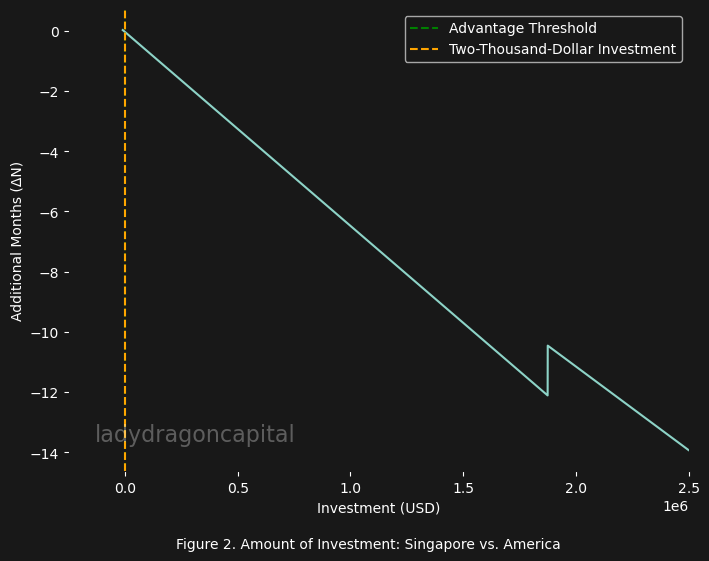

In [4]:
# set the style to a dark theme
plt.style.use("dark_background")

# match website background
plt.rcParams["figure.facecolor"] = "#181818"
plt.rcParams["axes.facecolor"] = "#181818"
plt.rcParams["axes.edgecolor"] = "#181818"

# set values
I_dom = 0.0335
P_sgp = 37500
C_dom = 1164.4
F_dom = 0
P_visasgp = 1875000
I_sgp = 0.026
t_sgp = 0
C_sgp = 1120
F_sgp = 50


fig, ax = plt.subplots(figsize=(8, 6))

# ind the value of p that minimizes the absolute value of the objective function
result = minimize(absolute_objective_function, 0.5, args=(I_dom, C_dom, F_dom, P_visasgp, I_sgp, t_sgp, C_sgp, F_sgp))

# Extract the optimal value of x
threshold_p = result.x[0]

# generate p/ΔN pairs
p_values = np.arange(-10000, 2500000, 500)
delta_n_values = np.array([calculate_delta_n(I_dom, p, C_dom, F_dom, P_visasgp, I_sgp, t_sgp, C_sgp, F_sgp) for p in p_values])

# plotting the data
plt.plot(p_values, delta_n_values)

# plot threshold p value and target 2000 value
plt.axvline(x=threshold_p, color='green', linestyle='--', label='Advantage Threshold')
plt.axvline(x=2000, color='orange', linestyle='--', label='Two-Thousand-Dollar Investment')

# add watermark
add_watermark(ax, 1, 1)

# adding labels and title
plt.xlabel("Investment (USD)")
plt.ylabel("Additional Months (ΔN)")
plt.xlim([-250000, 2500000])
# set title
plt.suptitle(
    f"Figure {fig_count}. Amount of Investment: Singapore vs. America", y=0.0001, fontsize=10
)
fig_count += 1

# displaying the plot
plt.legend()
plt.show()

## Conclusion ##

As demonstrated in the first example (Ecuador vs. America), investing offshore can offer the following advantages:

+ Portfolio diversification, and reducing overall risk;
+ Higher interest rates;
+ Lower cost of living.

However, to access these advantages, investors must meet the minimum investment requirements, such as the 40,000 USD needed for Ecuador's investor visa. For our 2000-dollar fund, specifically considering the option of certificate of deposit, domestic investment remains the more favorable option.

In future articles, we will continue to explore the appropriate percentage of wealth to allocate toward investor visas to optimize the advantage, as well as examine other asset classes beyond certificates of deposit.